<a href="https://colab.research.google.com/github/donkey-king-kong/CSCI-4907---NLU/blob/main/(GWU)_CSCI_4907_NLU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecting Hate Speech in Tweets - Cyberbullying
Group Members:
> - Zhan You Lau
> - Yu Chen Law
> - Kieran E Kai Voo
> - Joshua, Tse Ern Foo

# Introduction
Social media has become ubiquitous in our everyday communication which contributes to the increased prevalence of cyberbullying. However, cyberbullying detection is particularly challenging in a multilabel setting as harmful content may belong to multiple overlapping categories like threats, insults, or implicit aggression. These categories often rely on subtle linguistic cues such as sarcasm and contextual ambiguity. This makes accurate classification difficult.

## Problem Formulation
Our project examines how different modeling approaches handle the complexities of multilabel cyberbullying detection as well as evaluates their strengths and limitations beyond overall performance metrics.

### Key Objective
- Perform data preparation, preprocessing, and exploratory analysis
- Implement classical machine learning models and Bi-LSTM for comparison
- Evaluate and compare model performance using multilabel metrics
- Conduct structured error analysis to examine linguistic failure cases

## Trigger Warning
These tweets either describe a bullying event or are the offense themselves, therefore explore it to the point where you feel comfortable.

In [3]:
import pandas as pd
df = pd.read_csv('cyberbullying_tweets.csv')
df.head()

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


## Data Preparation & Cleaning
The following actions are performed to the data present in our dataset to bring a uniformity and remove any stray characters to improve effeciency of our model.

In [4]:
import string
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
# Function to make text lowercase
def make_lowercase(text):
    lower = text.lower()
    return lower

# Function to remove mentions (@username) from text
def remove_mentions(text):
    clean_text = re.sub(r'@\S+', '', text)
    return clean_text

# Function to remove punctuation from text
def remove_punctuation(text):
    translator = str.maketrans('', '', string.punctuation)
    clean_text = text.translate(translator)
    return clean_text

# Function to remove URLs from text
def remove_url(text):
    clean_text = re.sub(r'https?://\S+|www\.\S+', '', text)
    return clean_text

# Function to remove extra whitespaces from text
def remove_extraspace(text):
    words = text.split()
    updated_text = " ".join(words)
    return updated_text

# Function to remove stopwords from text
def remove_stopwords(text):
    tweet_words = text.split()
    stop_words = set(stopwords.words('english'))
    filtered_words = [word for word in tweet_words if word not in stop_words]
    filtered_tweet = " ".join(filtered_words)
    return filtered_tweet

# Function to remove HTML characters (e.g., &) from text
def remove_strayHTML(text):
    clean_text = text = re.sub(r'&\S+;', '', text)
    return clean_text

# Function to remove numbers from text
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

# Function to remove picture links (e.g., pic.twitter.com) from text
def remove_piclinks(text):
    return re.sub(r'pic\.twitter\.com/\S+', '', text)

# Function to remove short words (length <= 2) from text
def remove_shortwords(text):
    words = text.split()
    long_words = [word for word in words if len(word) > 2]
    return ' '.join(long_words)

## Testing Data Cleaning Functions (To be Removed)

In [6]:
def test_make_lowercase():
    assert make_lowercase("HeLLo!") == "hello!"
    assert make_lowercase("") == ""

def test_remove_mentions():
    assert remove_mentions("@bob hi") == " hi"
    assert remove_mentions("hi @bob") == "hi "
    assert remove_mentions("hi") == "hi"

def test_remove_punctuation():
    assert remove_punctuation("hi, world!") == "hi world"
    assert remove_punctuation("no_punct") == "nopunct"
    assert remove_punctuation("") == ""

def test_remove_url():
    assert remove_url("visit http://example.com now") == "visit  now"
    assert remove_url("visit https://example.com now") == "visit  now"
    assert remove_url("visit www.example.com now") == "visit  now"

def test_remove_extraspace():
    assert remove_extraspace("  hi   there  ") == "hi there"
    assert remove_extraspace("hi") == "hi"
    assert remove_extraspace("") == ""

def test_remove_stopwords():
    _ = stopwords.words("english")
    assert remove_stopwords("this is a test") == "test"
    assert remove_stopwords("the quick brown fox") == "quick brown fox"

def test_remove_strayHTML():
    assert remove_strayHTML("Tom &amp; Jerry") == "Tom  Jerry"
    assert remove_strayHTML("no html") == "no html"

def test_remove_numbers():
    assert remove_numbers("a1b2c3") == "abc"
    assert remove_numbers("2026-02-25") == "--"
    assert remove_numbers("no nums") == "no nums"

def test_remove_piclinks():
    assert remove_piclinks("check pic.twitter.com/abc") == "check "
    assert remove_piclinks("no pic link") == "no pic link"

def test_remove_shortwords():
    assert remove_shortwords("I am at NTU") == "NTU"
    assert remove_shortwords("to be or not to be") == "not"

def run_all_tests():
    tests = [
        test_make_lowercase,
        test_remove_mentions,
        test_remove_punctuation,
        test_remove_url,
        test_remove_extraspace,
        test_remove_stopwords,
        test_remove_strayHTML,
        test_remove_numbers,
        test_remove_piclinks,
        test_remove_shortwords,
    ]
    for t in tests:
        t()
    print(f"Passed {len(tests)} tests")

run_all_tests()

Passed 10 tests


In [7]:
# A single function to preprocess the entire tweets data
def clean_text(text):
    text=make_lowercase(text)
    text=remove_stopwords(text)
    text=remove_mentions(text)
    text=remove_strayHTML(text)
    text=remove_punctuation(text)
    text=remove_url(text)
    text=remove_extraspace(text)
    text=remove_numbers(text)
    text=remove_piclinks(text)
    text=remove_shortwords(text)
    return text

In [11]:
# Apply the clean_text function to each tweet in the 'tweet_text' column of the DataFrame
df['tweet_clean'] = [clean_text(tweet) for tweet in df['tweet_text']]
df.head(10)

,tweet_text,cyberbullying_type,tweet_clean
0,"In other words #katandandre, your food was cra...",not_cyberbullying,words katandandre food crapilicious mkr
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,aussietv white mkr theblock imacelebrityau tod...
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,classy whore red velvet cupcakes
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,meh thanks heads concerned another angry dude ...
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,isis account pretending kurdish account like i...
5,"@Raja5aab @Quickieleaks Yes, the test of god i...",not_cyberbullying,yes test god good bad indifferent weird whatev...
6,Itu sekolah ya bukan tempat bully! Ga jauh kay...,not_cyberbullying,itu sekolah bukan tempat bully jauh kaya neraka
7,Karma. I hope it bites Kat on the butt. She is...,not_cyberbullying,karma hope bites kat butt nasty mkr
8,@stockputout everything but mostly my priest,not_cyberbullying,everything mostly priest
9,Rebecca Black Drops Out of School Due to Bully...,not_cyberbullying,rebecca black drops school due bullying


## Exploratory Data Analysis
To analyse and visualze the data we have cleaned in order to understand its underlying patterns, relationships and anomalies. We will be using data visualization techniques in hopes of generating insights that could help us better understand the data before applying any models or conducting any hypothesis testing.

### Preliminary Examination - The Numbers Game
The "numbers game" is used in our exploratory data analysis where we systematically examine the numerical data to identify patterns, trends and anmoalies. 

Here, we plot the number of tweets belonging to each category in the dataset as well as their relative percentages.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sb

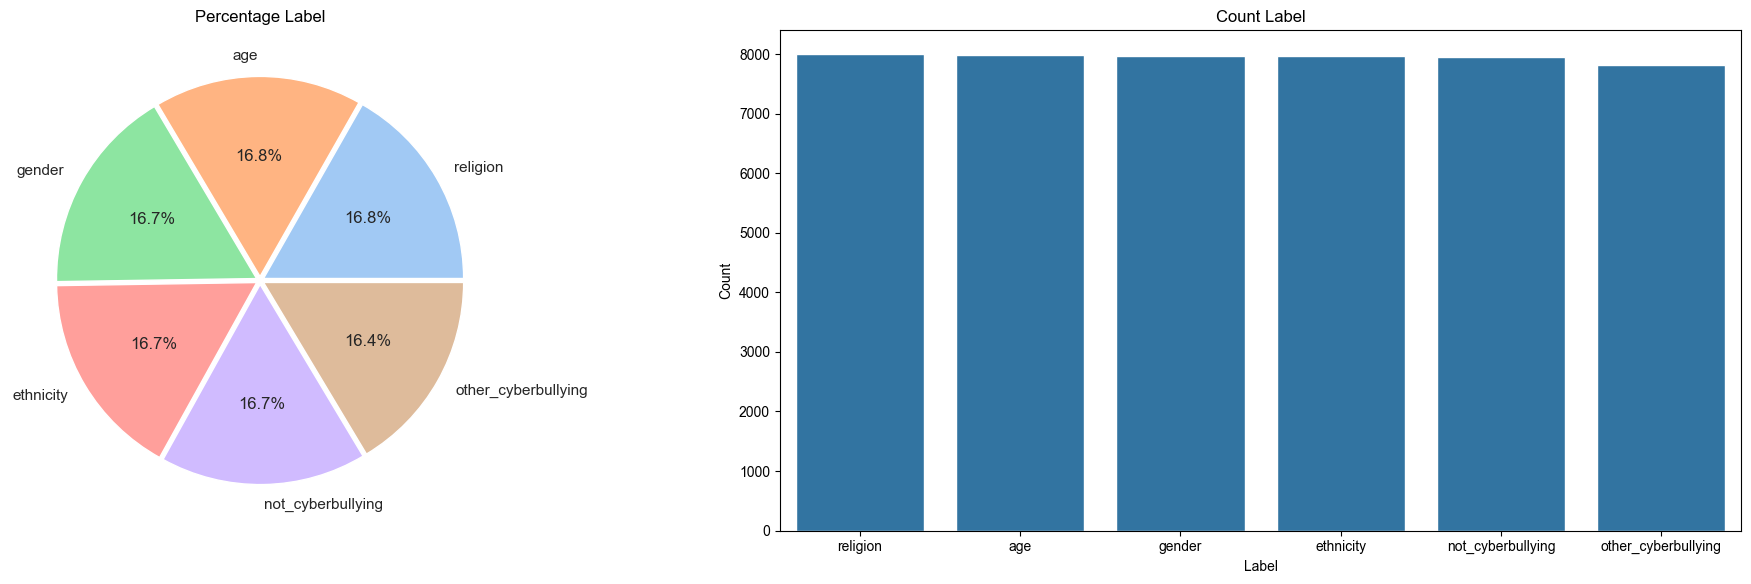

In [10]:
# Count occurrences of each label in 'cyberbullying_type' column
label_count = df['cyberbullying_type'].value_counts()

# Create subplots for pie chart and bar chart
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Set seaborn theme and palette
sb.set_theme(style='darkgrid', palette='pastel')

# Define colors and explode values for pie chart
color = sb.color_palette('pastel')
explode = [0.02] * len(label_count)

# Plot pie chart showing percentage of each label
axes[0].pie(label_count.values, labels=label_count.index, autopct='%1.1f%%', colors=color, explode=explode)
axes[0].set_title('Percentage Label')

# Plot bar chart showing count of each label
sb.barplot(x=label_count.index, y=label_count.values, ax=axes[1])
axes[1].set_title('Count Label')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')

# Adjust layout to prevent overlapping of labels
plt.tight_layout()

# Display the plots
plt.show()

### Most Common Words by Tokenization
Here, we used tokenization to break down a piece of text like sentences or paragraphs into individual worlds or "tokens". From this plot, we can see the most common words in the tweets of our data.

In [12]:
from collections import Counter
import numpy as np

In [13]:
# Define a function to tokenize the text column
def Tokenize(column, seq_len):
    # Create a corpus of words from the text column
    corpus = [word for text in column for word in text.split()]

    # Count the occurrences of each word in the corpus
    count_words = Counter(corpus)

    # Sort words based on their frequencies
    sorted_words = count_words.most_common()

    # Assign unique integer indices to words
    vocab_to_int = {w: i + 1 for i, (w, c) in enumerate(sorted_words)}

    # Tokenize each text in the column using the vocabulary
    text_int = []
    for text in column:
        r = [vocab_to_int[word] for word in text.split()]
        text_int.append(r)

    # Pad/truncate sequences to match the specified sequence length
    features = np.zeros((len(text_int), seq_len), dtype=int)
    for i, review in enumerate(text_int):
        if len(review) <= seq_len:
            zeros = list(np.zeros(seq_len - len(review)))
            new = zeros + review
        else:
            new = review[: seq_len]
        features[i, :] = np.array(new)

    return sorted_words, features

#### Simple test of Tokenize Function

In [22]:
# Sample
sample_texts = [
    "you are stupid",
    "i hate you",
    "you are very stupid"
]

# Manually Count
corpus = []
for text in sample_texts:
    for word in text.split():
        corpus.append(word)

count_words = Counter(corpus)
sorted_words_manual = count_words.most_common()

print("Manual Sorted Words:")
print(sorted_words_manual)

# Manually map vocabulary
vocab_to_int_manual = {}
for i, (word, _) in enumerate(sorted_words_manual):
    vocab_to_int_manual[word] = i + 1

print("\nManual Vocab Mapping:")
print(vocab_to_int_manual)

# Manual tokenization
text_int_manual = []
for text in sample_texts:
    tokens = []
    for word in text.split():
        tokens.append(vocab_to_int_manual[word])
    text_int_manual.append(tokens)

# Manual Padding
seq_len = 5
features_manual = np.zeros((len(text_int_manual), seq_len), dtype=int)

for i, review in enumerate(text_int_manual):
    if len(review) <= seq_len:
        zeros = list(np.zeros(seq_len - len(review)))
        new = zeros + review
    else:
        new = review[:seq_len]
    features_manual[i, :] = np.array(new)

print("\nManual Tokenized & Padded Features:")
print(features_manual)

Manual Sorted Words:
[('you', 3), ('are', 2), ('stupid', 2), ('i', 1), ('hate', 1), ('very', 1)]

Manual Vocab Mapping:
{'you': 1, 'are': 2, 'stupid': 3, 'i': 4, 'hate': 5, 'very': 6}

Manual Tokenized & Padded Features:
[[0 0 1 2 3]
 [0 0 4 5 1]
 [0 1 2 6 3]]


In [23]:
# Test the function
sorted_words, features = Tokenize(sample_texts, seq_len=5)

print("\nSorted Words (by frequency):")
print(sorted_words)

print("\nTokenized & Padded Features:")
print(features)


Sorted Words (by frequency):
[('you', 3), ('are', 2), ('stupid', 2), ('i', 1), ('hate', 1), ('very', 1)]

Tokenized & Padded Features:
[[0 0 1 2 3]
 [0 0 4 5 1]
 [0 1 2 6 3]]


### Apply Tokenizer Function

C:\Users\user\AppData\Local\Temp\ipykernel_20548\1045715215.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.barplot(x=keys, y=values, palette='mako')


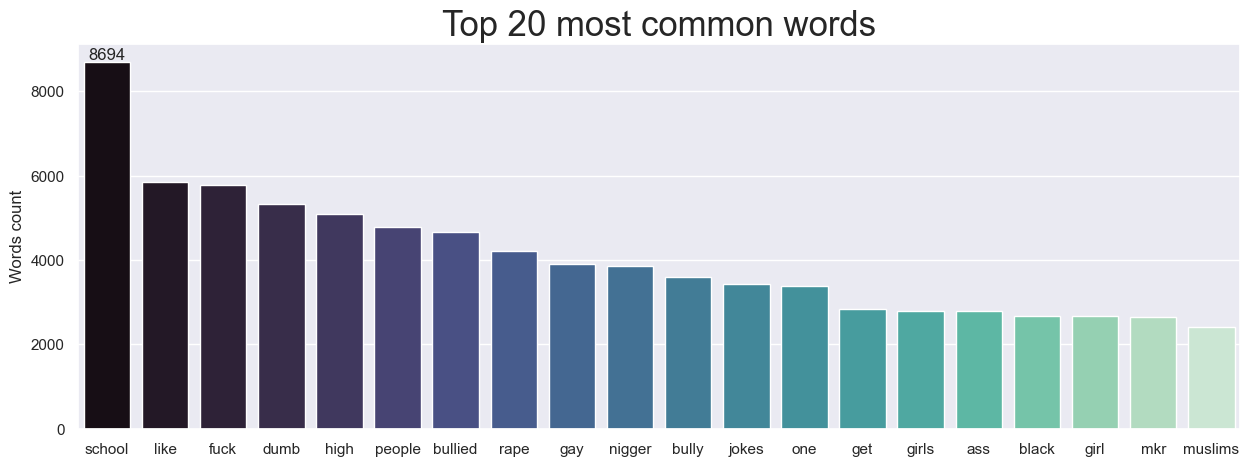

In [24]:
# Tokenize the tweet_clean column
vocabulary, tokenized_column = Tokenize(df["tweet_clean"], 300)

# Extract the top 20 most common words and their frequencies from the vocabulary
keys = []
values = []
for key, value in vocabulary[:20]:
    keys.append(key)
    values.append(value)

# Plotting the top 20 most common words
plt.figure(figsize=(15, 5))
ax = sb.barplot(x=keys, y=values, palette='mako')
plt.title('Top 20 most common words', size=25)
ax.bar_label(ax.containers[0])
plt.ylabel("Words count")
plt.show()